# 3. Learn a noise predictor, then sample (Draft)

## The question

The previous notebook sampled successfully with an analytic score. Real datasets do not provide a density or its derivatives. Can ordinary regression on corrupted data estimate the score needed by the sampler?

We will train a small neural network, compare its predictions with a known reference, and then generate samples. The data remain synthetic so that learning error can be measured directly.

**Background:** Gaussian corruption, conditional expectation, and gradient descent. The required sampling formulas are restated below. **Setup:** NumPy, SciPy, Matplotlib, and PyTorch on a CPU. No dataset download or GPU is needed. Run all cells in order.

## 1. Fix the data distribution and notation

Use

$$p_0(x)=\tfrac12\mathcal N(x;-2,0.25)+\tfrac12\mathcal N(x;2,0.25),
\qquad \beta=8,\qquad \alpha_t=e^{-\beta t/2}.$$

Draw noisy observations by

$$X_t=\alpha_tX_0+\sqrt{1-\alpha_t^2}\,\varepsilon,
\qquad \varepsilon\sim\mathcal N(0,1),$$

with independent data and noise. Data time is 0, terminal time is 1, and generation runs backward. Training uses $t\in[t_{\min},1]$ with $t_{\min}=0.01$.

The exact noisy density is a Gaussian mixture with component means $\alpha_t m_j$, where $m_1=-2$, $m_2=2$, and variance $V_t=0.25\alpha_t^2+1-\alpha_t^2$. Its reference score is

$$s_t(x)=\sum_jw_j(x,t)\frac{\alpha_tm_j-x}{V_t},\qquad
w_j(x,t)=\frac{\tfrac12\mathcal N(x;\alpha_tm_j,V_t)}{p_t(x)}.$$

The first cell supplies the reference density, score, CDF, and sampler helpers. The exact score is used for evaluation and the baseline sampler, **not as a training target**.

The ODE helper uses the backward explicit-Euler update

$$x_{t-h}=x_t+\frac{\beta h}{2}[x_t+s_t(x_t)].$$

Replacing $s_t$ by a learned estimate will be the only change in the final comparison.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp, ndtr
rng = np.random.default_rng(20260930)
started = time.perf_counter()
beta = 8.0
t_min = 0.01
means = np.array([-2., 2.])
V0 = 0.25

def alpha(t):
    return np.exp(-beta * np.asarray(t) / 2)

def parameters(t):
    a = alpha(t)
    return a * means, a*a*V0 + 1-a*a

def sample_data(n):
    return rng.choice(means, n) + np.sqrt(V0)*rng.normal(size=n)

def sample_marginal(n, t):
    a = alpha(t)
    return a*sample_data(n) + np.sqrt(1-a*a)*rng.normal(size=n)

def component_weights(x, t):
    m, V = parameters(t)
    logw = -(np.asarray(x)[..., None]-m)**2/(2*V)
    return np.exp(logw-logsumexp(logw, axis=-1, keepdims=True))

def density(x, t):
    m, V = parameters(t)
    return np.mean(np.exp(-(np.asarray(x)[...,None]-m)**2/(2*V))/np.sqrt(2*np.pi*V), axis=-1)

def cdf(x, t):
    m, V = parameters(t)
    return np.mean(ndtr((np.asarray(x)[...,None]-m)/np.sqrt(V)), axis=-1)

def score(x, t):
    m, V = parameters(t)
    return np.sum(component_weights(x,t)*(m-np.asarray(x)[...,None])/V, axis=-1)

def ecdf_error(x, t):
    x = np.sort(x)
    F = cdf(x,t)
    n = len(x)
    return max(np.max(np.arange(1,n+1)/n-F), np.max(F-np.arange(n)/n))

def sample_reverse(x1, steps=400, stochastic=False, score_fn=score, end=t_min, keep=8):
    x = np.asarray(x1).copy()
    times = np.linspace(1.,end,steps+1)
    traces = [x[:keep].copy()]
    for t, next_t in zip(times[:-1],times[1:]):
        h = t-next_t
        s = score_fn(x,t)
        # Increasing reverse clock: -f + g^2*s for SDE; half score for ODE.
        x += h*beta*(0.5*x+(1. if stochastic else 0.5)*s)
        if stochastic:
            x += np.sqrt(beta*h)*rng.normal(size=x.shape)
        traces.append(x[:keep].copy())
    return x, times, np.asarray(traces)


## 2. Construct a regression problem from forward corruption

For every update, draw clean data $x_0$, a time $t$, and noise $\varepsilon$. Compute $x_t$ using the forward formula. The network receives $(x_t,t)$ and predicts the added noise:

$$\varepsilon_\theta:\mathbb R\times[t_{\min},1]\to\mathbb R.$$

Its population training objective is

$$\mathcal J(\theta)=\mathbb E\left[
(\varepsilon-\varepsilon_\theta(X_t,t))^2\right].$$

Several clean-data/noise pairs can produce the same noisy observation. Consequently, the best possible squared-error predictor is the conditional mean

$$\varepsilon_*(x,t)=\mathbb E[\varepsilon\mid X_t=x,t],$$

not a guaranteed recovery of the particular noise draw used to create each example. To verify this, let $m(X_t,t)=\mathbb E[\varepsilon\mid X_t,t]$ and expand conditionally:

$$\mathbb E[(\varepsilon-h(X_t,t))^2\mid X_t,t]
=\operatorname{Var}(\varepsilon\mid X_t,t)+(m(X_t,t)-h(X_t,t))^2.$$

The first term does not depend on the predictor, so the second is minimized at $h=m$.

## 3. Why this estimates the score

The known conditional corruption score is

$$\partial_x\log p_t(x\mid x_0)
=-\frac{x-\alpha_tx_0}{1-\alpha_t^2}.$$

Differentiating the marginal mixture and using Bayes' rule gives

$$s_t(x)=\mathbb E[\partial_x\log p_t(x\mid X_0)\mid X_t=x]
=-\frac{\mathbb E[\varepsilon\mid X_t=x]}{\sqrt{1-\alpha_t^2}}.$$

Thus a noise predictor defines a score estimate through

$$s_\theta(x,t)=-\frac{\varepsilon_\theta(x,t)}{\sqrt{1-\alpha_t^2}}.$$

The conversion explains why noise regression is useful for sampling. It also exposes a numerical issue: at small noise, score error is noise-prediction error divided by a small number. We avoid $t=0$, where this conversion is undefined, and evaluate errors separately at several positive times.

## 4. Implement the network and optimizer

The small network uses two hidden layers of 64 units with smooth SiLU activations. Its inputs are position, time, and four sinusoidal time features. Time must be an input because the required prediction changes with the noise level.

The code below defines, but does not yet run, 2,500 training updates. Each update uses 512 freshly generated data points, independent noise, and uniformly sampled times. Adam updates the network using the mean squared error. `make_learned_score` implements the displayed conversion.

All code runs on the CPU. A fixed seed makes the comparison reproducible in the tested environment.

In [2]:
import torch
from torch import nn
torch.set_num_threads(2)
torch.manual_seed(20260930)

class NoiseNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(6,64),nn.SiLU(),nn.Linear(64,64),nn.SiLU(),nn.Linear(64,1))
    def forward(self,x,t):
        features = torch.stack([x,t,torch.sin(np.pi*t),torch.cos(np.pi*t),torch.sin(2*np.pi*t),torch.cos(2*np.pi*t)],-1)
        return self.net(features).squeeze(-1)

def train_noise(steps=2500):
    model=NoiseNet()
    optimizer=torch.optim.Adam(model.parameters(),lr=2e-3)
    losses=[]
    for k in range(steps):
        x0=(torch.randint(0,2,(512,))*2-1).float()*2 + 0.5*torch.randn(512)
        t=t_min+(1-t_min)*torch.rand(512)
        a=torch.exp(-beta*t/2)
        eps=torch.randn(512)
        xt=a*x0+torch.sqrt(1-a*a)*eps
        loss=(model(xt,t)-eps).square().mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    model.eval()
    return model,np.asarray(losses)

def make_learned_score(model):
    @torch.no_grad()
    def learned_score(x,t):
        xx=torch.as_tensor(x,dtype=torch.float32)
        tt=torch.full_like(xx,float(t))
        return -model(xx,tt).numpy()/np.sqrt(1-alpha(t)**2)
    return learned_score


## 5. Train and evaluate at several times

The next cell trains the model and plots a 50-update moving average of the noise loss. It then compares exact and learned score curves at $t=0.01,0.1,0.5$.

We also report a marginal-weighted score error,

$$\mathbb E_{X_t\sim p_t}[(s_\theta(X_t,t)-s_t(X_t))^2],$$

estimated on new samples. This weights positions according to the distribution encountered at that time. Uniform error across a wide spatial grid would answer a different question by assigning substantial importance to rarely visited tails.

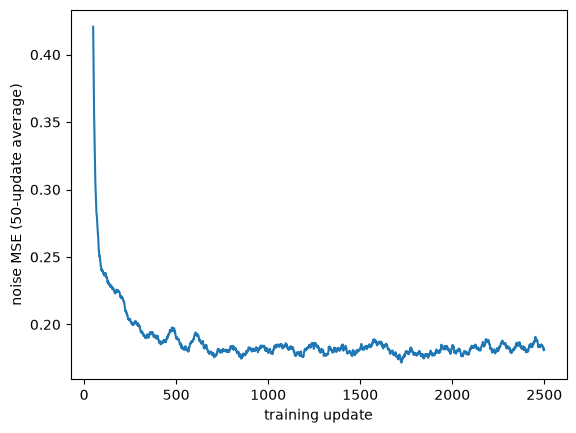

t=0.01: marginal-weighted score MSE=0.3956
t=0.1: marginal-weighted score MSE=0.0038
t=0.5: marginal-weighted score MSE=0.0002


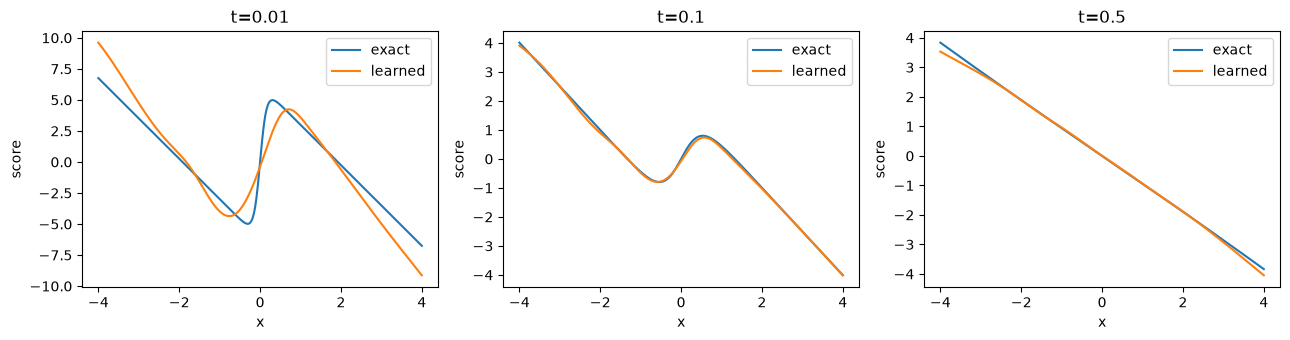

In [3]:
model,losses=train_noise()
learned_score=make_learned_score(model)
plt.plot(np.arange(49,len(losses)),np.convolve(losses,np.ones(50)/50,mode="valid"))
plt.xlabel("training update"); plt.ylabel("noise MSE (50-update average)"); plt.show()
grid=np.linspace(-4,4,400)
fig,axes=plt.subplots(1,3,figsize=(13,3.5))
for ax,t in zip(axes,[.01,.1,.5]):
    ax.plot(grid,score(grid,t),label="exact")
    ax.plot(grid,learned_score(grid,t),label="learned")
    ax.set(title=f"t={t}",xlabel="x",ylabel="score"); ax.legend()
    # Evaluate under the actual noisy marginal, not uniformly in the far tails.
    test=sample_marginal(10000,t)
    print(f"t={t}: marginal-weighted score MSE={np.mean((learned_score(test,t)-score(test,t))**2):.4f}")
plt.tight_layout(); plt.show()

### Reading the training results

The recorded score MSEs are approximately 0.396, 0.0038, and 0.0002 at the three displayed times. The low-noise score is noticeably less accurate. This is compatible with a reasonable overall noise loss: the conversion amplifies noise-prediction error near $t=0$, and a single average loss does not report accuracy uniformly across times.

The loss is not expected to reach zero even for an ideal predictor, because the realized noise is uncertain given the network input. Increasing training updates may reduce approximation or optimization error; it cannot remove that conditional uncertainty from the targets.

## 6. Use the estimate in the sampling field

The learned probability-flow field is

$$v_\theta(x,t)=-\frac\beta2\left[x-
\frac{\varepsilon_\theta(x,t)}{\sqrt{1-\alpha_t^2}}\right].$$

Once the model is trained, its parameters stay fixed during sampling. Start from the exact terminal law $p_1$, and run 400 Euler steps to $t_{\min}$. Using the exact terminal mixture here intentionally removes Gaussian-prior approximation from the comparison.

We use the same initial particles and the same solver settings for two runs: one with the exact score and one with the learned score. This controls the initialization and discretization procedure while changing the field estimate. The target density is $p_{0.01}$, since the sampler stops there.

The next cell reports each output's empirical CDF discrepancy from that target and the mean distance between paired outputs. It saves the trained model for optional reuse in Notebook 4.

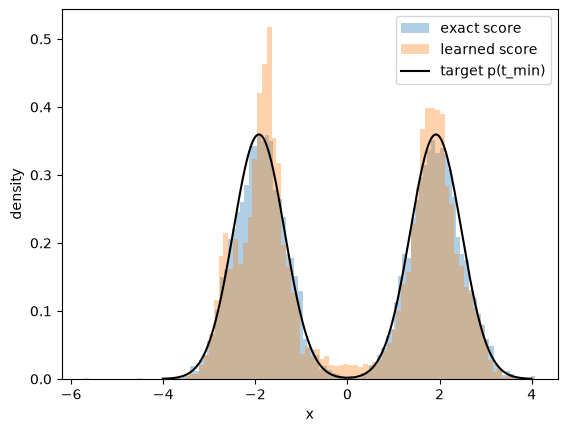

Exact-score ECDF error: 0.01225543204322821
Learned-score ECDF error: 0.03224285818810235
Paired mean output difference: 0.06356608082392023
Runtime: 2.4 s


In [4]:
x1=sample_marginal(6000,1.)
exact,_,_=sample_reverse(x1,steps=400)
learned,_,_=sample_reverse(x1,steps=400,score_fn=learned_score)
plt.hist(exact,bins=90,density=True,alpha=.35,label="exact score")
plt.hist(learned,bins=90,density=True,alpha=.35,label="learned score")
plt.plot(grid,density(grid,t_min),'k',label="target p(t_min)")
plt.xlabel("x"); plt.ylabel("density"); plt.legend(); plt.show()
print("Exact-score ECDF error:",ecdf_error(exact,t_min))
print("Learned-score ECDF error:",ecdf_error(learned,t_min))
print("Paired mean output difference:",np.mean(abs(exact-learned)))
assert np.isfinite(learned).all()
# Optional reuse by Notebook 4. The notebook also works without this file.
torch.save({"state_dict":model.state_dict(),"beta":beta,"t_min":t_min},"toy-noise.pt")
print(f"Runtime: {time.perf_counter()-started:.1f} s")

### Reading the generated samples

In the recorded run, the empirical CDF discrepancy is about 0.0123 for the exact-score sampler and 0.0322 for the learned-score sampler on 6,000 matched initial particles. Their paired mean output difference is about 0.0636. These values describe this small teaching experiment, not a universal performance level.

An empirical CDF discrepancy includes finite-sample and numerical effects. The matched setup makes the difference between the two runs informative about score estimation, but neither single discrepancy is pure estimation error.

## Exercises

1. Halve the training updates while keeping the initial sampling particles fixed. Which plots and metrics reveal the change?
2. Double the solver steps without retraining. Explain why this cannot correct a systematically wrong learned field.
3. Why does an excellent average noise loss not guarantee a small score error near $t_{\min}$?
4. If you initialize from a standard normal instead of exact $p_1$, what additional approximation have you introduced?

The next notebook uses the same learned score for posterior-mean denoising and compares that estimate with posterior samples.